<a href="https://colab.research.google.com/github/aburafiar/Data-Science/blob/Project/EDA_Phase_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is one of the most critical skills in data science — handle missing data wrong and your entire analysis is garbage.Good. Now let's go deep. Missing data is not just a technical problem — it is a thinking problem. You must ask why the data is missing before you decide what to do with it.

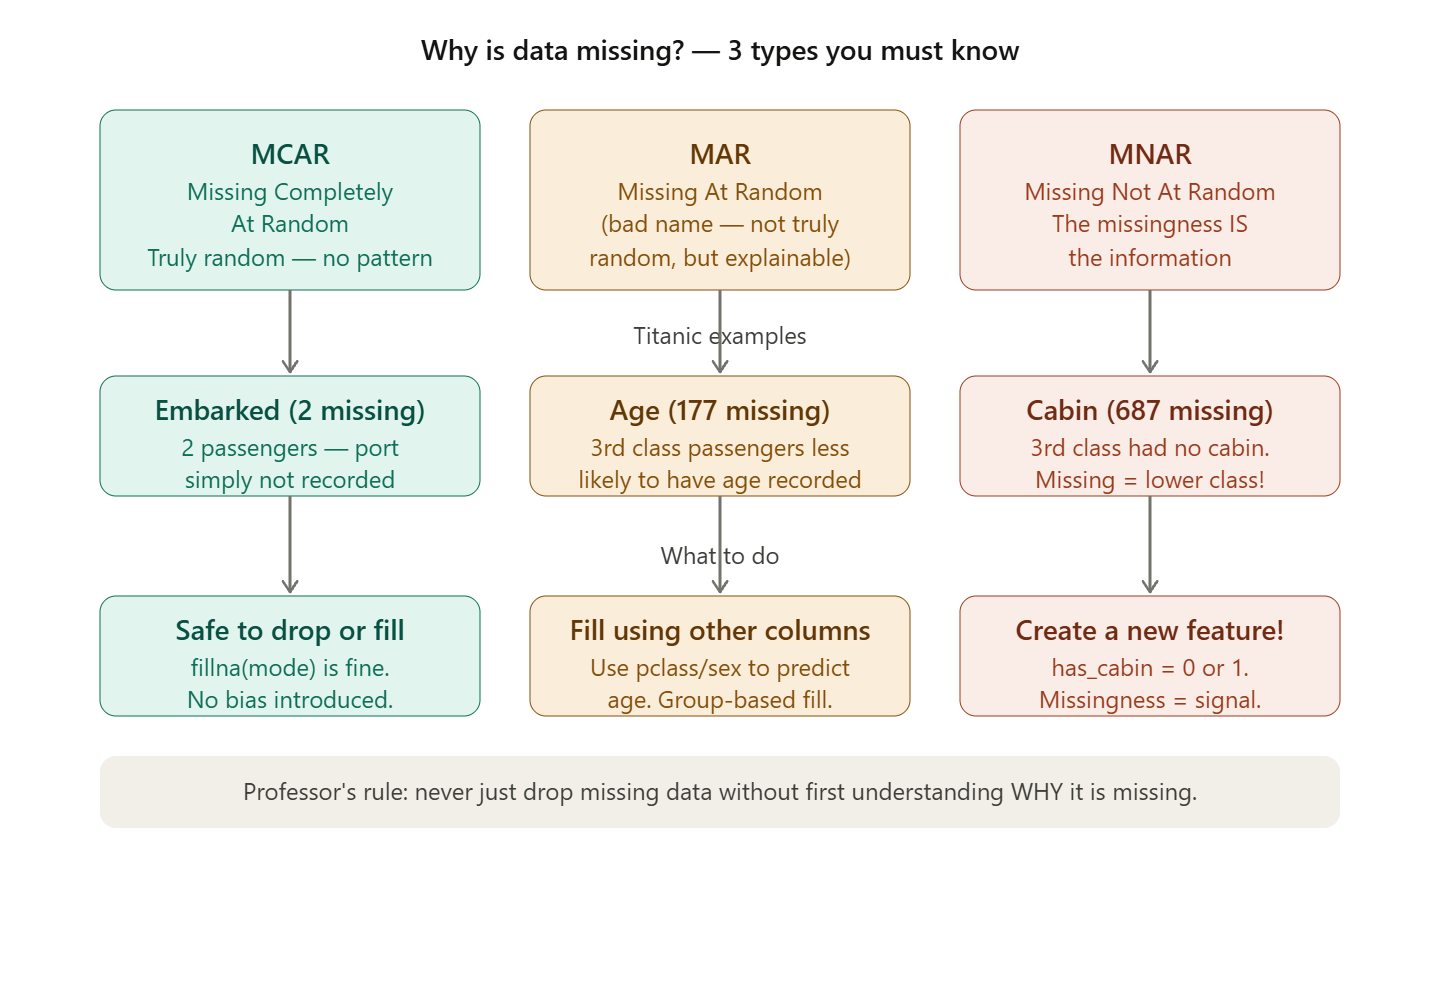

Now that you understand the why, let's go through every technique with real code

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = sns.load_dataset('titanic')

**Step 1 — Detect missing values**

 
 How many missing per column? 

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64
 
 As a percentage — much more useful for analysis 

survived       0.0
pclass         0.0
sex            0.0
age            0.0
sibsp          0.0
parch          0.0
fare           0.0
embarked       0.0
class          0.0
who            0.0
adult_male     0.0
embark_town    0.0
alive          0.0
alone          0.0
dtype: float64


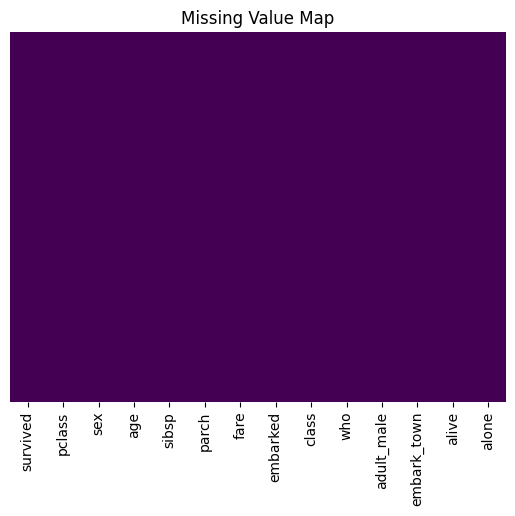

In [ ]:
print(' \n How many missing per column? \n')
print(df.isnull().sum())

print(' \n As a percentage — much more useful for analysis \n')
print(df.isnull().sum() / len(df) * 100)

# Quick visual heatmap

sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Map')
plt.show()

The heatmap shows yellow = missing, dark = present. You can see patterns at a glance — if a whole column is yellow, it's mostly useless.

Step 2 — The 4 strategies, with code
Now the interactive lab — every strategy side by side with its Titanic code

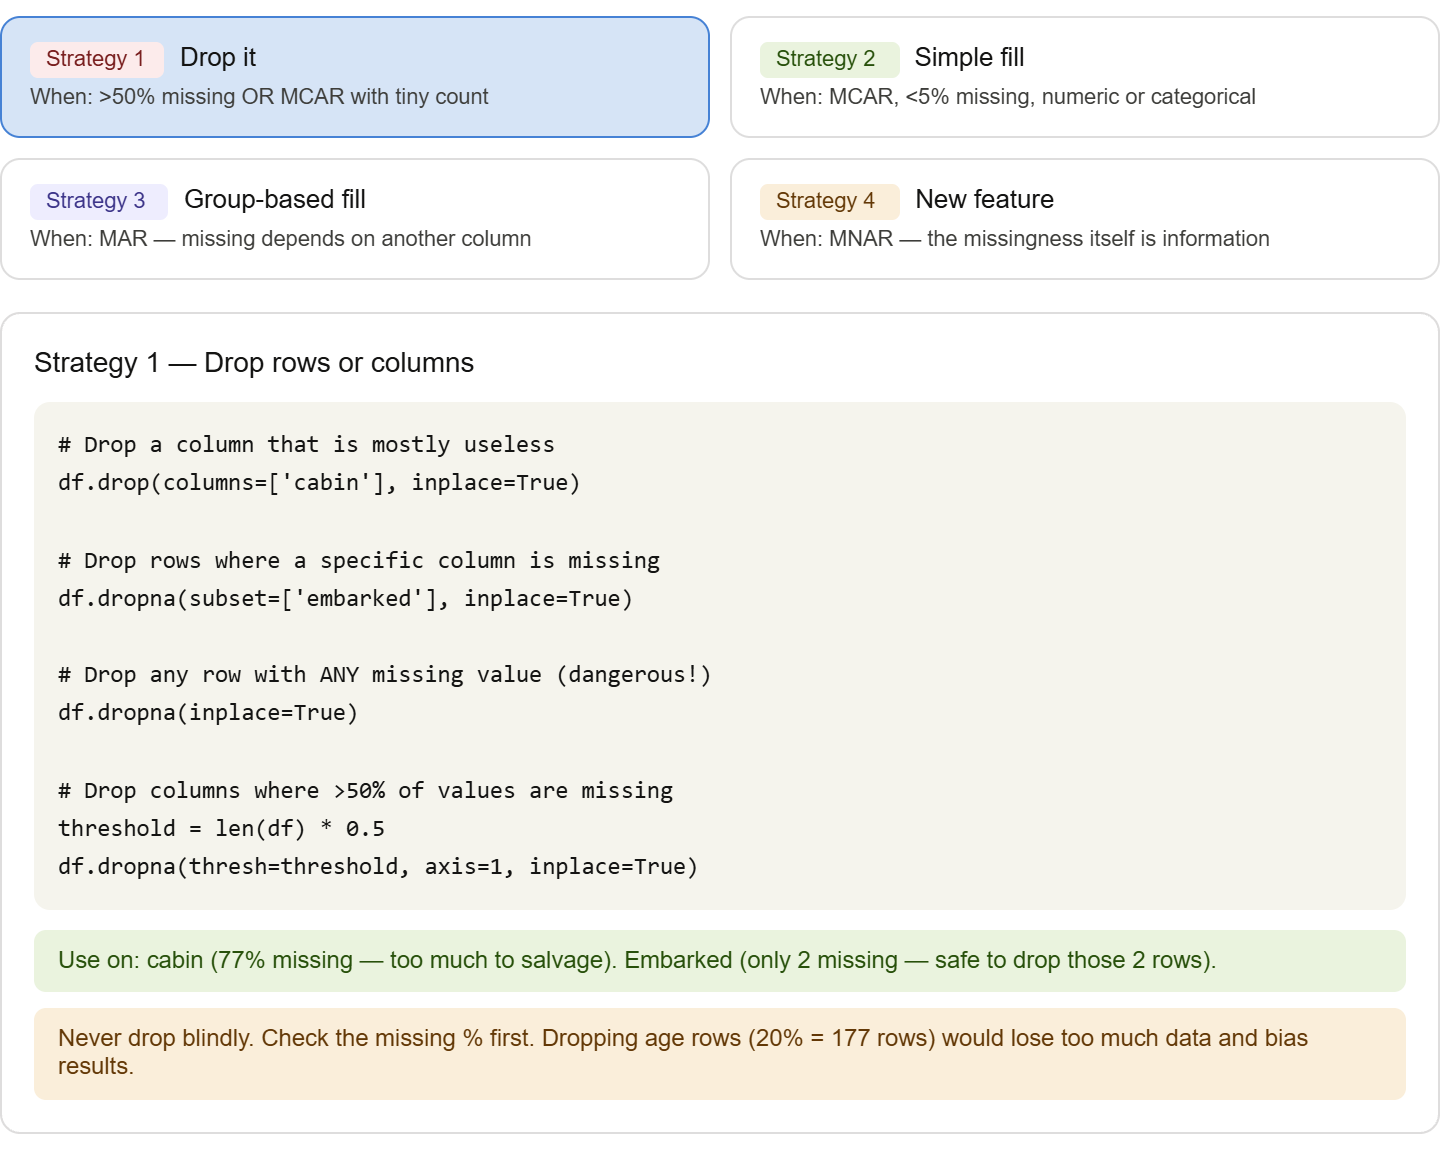


Strategy 1 — Drop rows or columns


In [ ]:

# Drop a column that is mostly useless
df.drop(columns=['deck'], inplace=True)

# Drop rows where a specific column is missing
df.dropna(subset=['embarked'], inplace=True)

# Drop any row with ANY missing value (dangerous!)
df.dropna(inplace=True)

# Drop columns where >50% of values are missing
threshold = len(df) * 0.5
df.dropna(thresh=threshold, axis=1, inplace=True)

Use on: cabin (77% missing — too much to salvage). Embarked (only 2 missing — safe to drop those 2 rows).
Never drop blindly. Check the missing % first. Dropping age rows (20% = 177 rows) would lose too much data and bias results.

Strategy 2 — Simple fill (fillna)

In [ ]:

# Fill numeric column with mean
df['age'].fillna(df['age'].mean(), inplace=True)

# Fill numeric column with median (better when outliers exist!)
df['age'].fillna(df['age'].median(), inplace=True)

# Fill categorical column with most frequent value (mode)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Fill with a constant
df['age'].fillna(0, inplace=True)  # rarely good
df['age'].fillna('Unknown', inplace=True)  # for text


/tmp/ipykernel_23111/2826941819.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
/tmp/ipykernel_23111/2826941819.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

Mean vs Median — which to pick?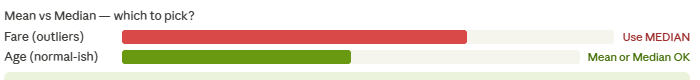
Fare (outliers)
Use MEDIAN
Age (normal-ish)
Mean or Median OK
Best for: embarked (mode), small % missing, MCAR data. Fast, simple, always the first thing to try.
Problem: filling all missing ages with 29.7 ignores that children and elderly have very different survival rates. Use Strategy 3 instead for age.

This is the professional approach. A 1st class female missing her age gets filled with 35, not 29.7. It respects the structure in the data.
Always check: df.groupby(...).size() to make sure every group has enough rows to compute a reliable median.

In [ ]:
# Age is MAR — it depends on pclass and sex.
# Richer passengers (pclass=1) tended to be older.
# So fill missing age using the MEDIAN age of that group.

# Step 1: see the group medians
df.groupby(['pclass','sex'])['age'].median()
# pclass  sex
# 1       female    35.0
# 1       male      40.0
# 2       female    28.0
# 2       male      30.0
# 3       female    21.5
# 3       male      25.0

# Step 2: fill each missing age with its group's median
df['age'] = df.groupby(['pclass','sex'])['age'] \
              .transform(lambda x: x.fillna(x.median()))

# Verify no more missing values in age
print(df['age'].isnull().sum())  # should print 0

0


This is the most powerful technique. You turned missing data into a useful predictor. The model now knows that has_cabin=0 means "probably 3rd class".
Always check if the missing flag actually correlates with your target (survived). If groupby shows no difference, the flag adds no value.

In [ ]:
# Cabin is MNAR. 3rd class passengers had no cabin.
# Missing cabin = lower class = lower survival chance.
# The FACT that cabin is missing is itself useful info!

# Step 1: create a binary flag BEFORE filling or dropping
df['has_cabin'] = df['deck'].notnull().astype(int)
# 1 = had a cabin (likely 1st/2nd class)
# 0 = no cabin (likely 3rd class)

# Step 2: verify the signal
df.groupby('has_cabin')['survived'].mean()
# has_cabin
# 0    0.299  ← 30% survival without cabin
# 1    0.667  ← 67% survival with cabin

# Step 3: now you can drop the original cabin column
df.drop(columns=['deck'], inplace=True)

# Same trick works for age
df['age_missing'] = df['age'].isnull().astype(int)

KeyError: 'deck'

Step 3 — The complete Titanic missing data solution
This is how a professional handles all three missing columns in one clean script:

In [ ]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset('titanic')

# ── 1. Cabin (MNAR — 77% missing) ──────────────────────────
df['has_cabin'] = df['deck'].notnull().astype(int)   # extract signal first
df.drop(columns=['deck'], inplace=True)              # then drop

# ── 2. Embarked (MCAR — only 2 missing) ────────────────────
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# ── 3. Age (MAR — 20% missing, depends on pclass+sex) ──────
df['age_missing'] = df['age'].isnull().astype(int)    # flag it first
df['age'] = df.groupby(['pclass', 'sex'])['age'] \
              .transform(lambda x: x.fillna(x.median()))

# ── 4. Final verification ───────────────────────────────────
print(df.isnull().sum())
# Every column should now show 0

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
has_cabin      0
age_missing    0
dtype: int64


/tmp/ipykernel_23111/962125723.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)


In [ ]:
import seaborn as sns
df = sns.load_dataset('titanic')

# For every column with missing values, check:
# does being missing correlate with survival?
for col in df.columns[df.isnull().any()]:
    mask = df[col].isnull()
    surv_missing = df[mask]['survived'].mean()
    surv_present = df[~mask]['survived'].mean()
    print(f"{col:12} | missing→survived={surv_missing:.2f} | present→survived={surv_present:.2f} | diff={abs(surv_missing-surv_present):.2f}")

age          | missing→survived=0.29 | present→survived=0.41 | diff=0.11
embarked     | missing→survived=1.00 | present→survived=0.38 | diff=0.62
deck         | missing→survived=0.30 | present→survived=0.67 | diff=0.37
embark_town  | missing→survived=1.00 | present→survived=0.38 | diff=0.62
